In [264]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


In [265]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    graph_gen,
    video_tools)


In [266]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"
QA_SGG = WORK_DIR / "outputs/gr_understaing_on_genstg_20250628_00:26:00_val_gemma3:4b-it-qat_20250620_20:39:00.jsonl"
SGG_GRAPHS = WORK_DIR / "outputs/sgg/sgg_1fps_batchframes_gemma3:4b-it-qat_20250628_00:26:00.jsonl"
#SGG_GRAPHS = WORK_DIR / "outputs/sgg/sgg2_1fps_batchedimages_gemma3:4b-it-qat_202500701_19:20:00.jsonl"
#SGG_GRAPHS = WORK_DIR / "outputs/sgg/sgg_1fps_notbatched_gemma3:4b-it-qat_202500701_14:50:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


In [267]:
gt_df = pd.read_json(STAR_VAL_SMALL)
gt_df['question_id'].duplicated().value_counts()


question_id
False    1048
Name: count, dtype: int64

In [268]:
gt_df[['video_id', 'start', 'end']].duplicated().value_counts()


False    921
True     127
Name: count, dtype: int64

In [269]:
videos_metadata = graph_gen.preprocess_videos_metadata(gt_df.to_dict(orient='records'))
len(videos_metadata)


921

The number of unique videos is coherent with we get from the gt_df.

In [270]:
sgg_df = pd.read_json(SGG_GRAPHS, lines=True)
sgg_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      914 non-null    object 
 1   start         914 non-null    float64
 2   end           914 non-null    float64
 3   chat_history  914 non-null    object 
 4   stsg          914 non-null    object 
dtypes: float64(2), object(3)
memory usage: 35.8+ KB


In [271]:
sgg_df[['video_id', 'start', 'end']].duplicated().value_counts()


False    914
Name: count, dtype: int64

In [272]:
sgg_df[['video_id', 'start', 'end']]


,video_id,start,end
0,ATV2F,0.0,4.000
1,9J166,9.9,17.500
2,ANA5N,4.3,10.300
3,Z6HEA,0.0,10.875
4,FRLW2,3.4,27.275
...,...,...,...
909,HL5OP,19.0,27.900
910,F9YMU,11.9,16.500
911,1333C,8.0,13.100
912,KU656,0.0,6.800


In [273]:
gt_vids = (
    gt_df
    .drop_duplicates(subset=['video_id', 'start', 'end'])[['video_id', 'start', 'end']]
    .astype(str)
    .agg("_".join, axis=1)
)

gt_vids = set(gt_vids)
len(gt_vids)


921

In [274]:
sgg_vids = (
    sgg_df[['video_id', 'start', 'end']]
    .astype(str)
    .agg("_".join, axis=1)
)

sgg_vids = set(sgg_vids)
len(sgg_vids)


914

In [275]:
gt_vids - sgg_vids
missing_vids = list(gt_vids - sgg_vids)
missing_vids

['GPR89_0.0_52.55',
 'MA15X_18.2_72.0',
 'AFTMI_0.0_37.8',
 'MA15X_21.0_67.275',
 'MA15X_21.8_60.1',
 'MA15X_21.8_67.275',
 'STAFD_3.3_46.4']

I am able to extract all the video. The missing stsg are probabaly due to failure of the VLM to produce the output.

In [276]:
sgg_df.iloc[4]['stsg']

"Okay, here’s a scene graph representing the objects and relationships observed in the video sequence, organized by frame and using the specified format:\n\n**Frame 0:**\n<scene_graph>\nman ---- holding_on_to ---- gas_cylinder\ngas_cylinder ---- labeled_as ---- “Indran”\nman ---- standing_near ---- wall\nwall ---- located_in ---- room\n</scene_graph>\n\n**Frame 1:**\n<scene_graph>\nman ---- leaning_against ---- wall\ngas_cylinder ---- located_next_to ---- man\nman ---- bending_towards ---- floor\nfloor ---- located_in ---- room\n</scene_graph>\n\n**Frame 2:**\n<scene_graph>\nman ---- reaching_for ---- floor\nfloor ---- containing ---- rug\nrug ---- located_on ---- floor\n</scene_graph>\n\n**Frame 3:**\n<scene_graph>\nman ---- crouching_down_towards ---- floor\nfloor ---- containing ---- red_balloon\nred_balloon ---- located_on ---- floor\n</scene_graph>\n\n**Frame 4:**\n<scene_graph>\nman ---- holding_red_balloon\nred_balloon ---- located_in_hand_of_man\n</scene_graph>\n\n**Frame 5:**\

In [277]:
print(sgg_df.iloc[4]['chat_history'][0]['content'])

You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [278]:
print(sgg_df.iloc[4]['chat_history'][2]['content'])

Now organize the objects and relationships you identified before into a formal scene graph using this format:
object1 ---- relationship ---- object2

The list of relationship predicates should be introduced for each frame should be introduce by the frame ID or 
name and finally by the tag <scene_graph> and terminated by the tag </scene_graph>.

For example:
Frame 0:
<scene_graph>
man ---- sitting_on ---- chair
dog ---- lying_under ---- table
book ---- on_top_of ---- shelf
...
</scene_graph>

Frame 2:
<scene_graph>
woman ---- on_the_left_of ---- man
...
<scene_graph>
...


Please follow these guidelines:
1. Create an adequate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relationships between objects
5. Verify that all objects you identified in step 1 appear in at least one relationship
6. You can condense multiple vis

In [279]:
re.findall("((?:Frame\s*\d*:\s*)?<scene_graph>(.*)</scene_graph>)", sgg_df.iloc[0]['stsg'], flags=re.DOTALL)[0][0]

'<scene_graph>\nFrame 0:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\nFrame 1:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\nFrame 2:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\nFrame 3:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\n</scene_graph>'

In [280]:
result = re.findall("<scene_graph>(.*)</scene_graph>", sgg_df.iloc[0]['stsg'], flags=re.DOTALL)
result


['\nFrame 0:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\nFrame 1:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\nFrame 2:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\nFrame 3:\nperson ---- holding ---- phone\nphone ---- to_ear_of ---- person\nperson ---- looking_up ---- direction\nperson ---- standing_in_front_of ---- closet\ncloset ---- containing ---- clothes\ncloset ---- containing ---- red_bag\n']

In [281]:
sgg_df['stsg_re'] = sgg_df['stsg'].apply(lambda x: match[0][0] if (match := re.findall(r"((?:Frame\s*\d*:\s*)?<scene_graph>(.*)</scene_graph>)", x, flags=re.DOTALL)) else "")
sgg_df['stsg_re'].apply(len).value_counts()


stsg_re
0       7
3965    3
1223    3
2854    2
2111    2
       ..
3661    1
1385    1
3254    1
2879    1
2198    1
Name: count, Length: 826, dtype: int64

In [282]:
contains_stsg_mask = sgg_df['stsg_re'].apply(len) > 0
sgg_df[~contains_stsg_mask]


,video_id,start,end,chat_history,stsg,stsg_re
105,Z97SD,25.1,30.7,"[{'role': 'user', 'content': 'You are an intel...",,
388,MD6P2,5.0,22.3,"[{'role': 'user', 'content': 'You are an intel...","Okay, here’s a scene graph representing the vi...",
572,EO6OI,33.6,38.9,"[{'role': 'user', 'content': 'You are an intel...",,
653,3B81O,0.0,21.6,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph representing the events i...,
724,6ZWSU,11.6,21.8,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph representing the objects ...,
826,DR7K0,13.9,22.7,"[{'role': 'user', 'content': 'You are an intel...",,
897,9632M,4.9,32.0,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph organized from the analys...,


In [283]:
sgg_df.loc[contains_stsg_mask, 'stsg_re'].iloc[1]


'<scene_graph>\n\n**Frame 0:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\nwindow ---- partially_obscured_by ---- curtain\n\n**Frame 1:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\n\n**Frame 2:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\n\n**Frame 3:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\n\n**Frame 4:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\n\n**Frame 5:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\nman ---- holding ---- box\n\n**Frame 6:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\nman ---- holding ---- box\n\n**Frame 7:**\nman ---- looking_at ---- window\nwindow ---- emitting_light ---- room\nman ---- holding ---- box\n\n</scene_graph>'

In [284]:
list(print(sgg_df[~contains_stsg_mask].iloc[i]['chat_history']) for i in range(1))


[{'role': 'user', 'content': 'You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:\n1. Look for recurring objects;\n2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;\n3. Pay attention to how the person interacts with its environment\n4. Understand the directional movement of the people and objects in the video\n5. Carefully analyze the chronological sequence of the events occurring in the video;\n6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer 

[None]

In [285]:
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    auth_token=hugg_auth_token
)


In [286]:
len(gemma3_tokenizer.tokenize(sgg_df[~contains_stsg_mask].iloc[0]['chat_history'][-1]['content']))


0

This answer has been cutoff because it was too long. Let's see if the model had hallucinated and stuck in a infinite loop:

In [287]:
print(sgg_df[~contains_stsg_mask].iloc[0]['chat_history'][-1]['content'])


Actually the answer seems legit (I may need to increase the cutoff window).  
Let's see if the same applies to the remaining answers:

In [288]:
sgg_df['answer_len'] = sgg_df["chat_history"].apply(lambda x: len(gemma3_tokenizer.tokenize(x[-1]['content'])))
sgg_df[~contains_stsg_mask]


,video_id,start,end,chat_history,stsg,stsg_re,answer_len
105,Z97SD,25.1,30.7,"[{'role': 'user', 'content': 'You are an intel...",,,0
388,MD6P2,5.0,22.3,"[{'role': 'user', 'content': 'You are an intel...","Okay, here’s a scene graph representing the vi...",,2048
572,EO6OI,33.6,38.9,"[{'role': 'user', 'content': 'You are an intel...",,,0
653,3B81O,0.0,21.6,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph representing the events i...,,2048
724,6ZWSU,11.6,21.8,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph representing the objects ...,,771
826,DR7K0,13.9,22.7,"[{'role': 'user', 'content': 'You are an intel...",,,0
897,9632M,4.9,32.0,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph organized from the analys...,,2048


In [289]:
print(sgg_df.loc[724]["chat_history"][-1]["content"])


Here’s a scene graph representing the objects and relationships observed in the video sequence, organized by frame and using the specified format:

**Frame 0:**
<scene_graph>
woman ---- sitting_on ---- floor
cat ---- near ---- woman
refrigerator ---- adjacent_to ---- door
boxes ---- stacked_on ---- floor
phone ---- on ---- floor
<scene_graph>

**Frame 1:**
<scene_graph>
woman ---- tying ---- shoe
cat ---- near ---- woman
refrigerator ---- adjacent_to ---- door
boxes ---- stacked_on ---- floor
phone ---- on ---- floor
<scene_graph>

**Frame 2:**
<scene_graph>
woman ---- tying ---- shoe
cat ---- near ---- woman
refrigerator ---- adjacent_to ---- door
boxes ---- stacked_on ---- floor
phone ---- on ---- floor
<scene_graph>

**Frame 3:**
<scene_graph>
woman ---- tying ---- shoe
cat ---- near ---- woman
refrigerator ---- adjacent_to ---- door
boxes ---- stacked_on ---- floor
phone ---- on ---- floor
<scene_graph>

**Frame 4:**
<scene_graph>
woman ---- untying ---- shoe
cat ---- near ---- wom

For this answer the model made a "small" hallucination. It used the format:  

Frame XXX:  
\<scene_graph\>  
...  
\<scene_graph\>  

Instead of:  
\<scene_graph\>  
Frame XXX:  
...  
\</scene_graph\>

<Axes: xlabel='answer_len', ylabel='Count'>

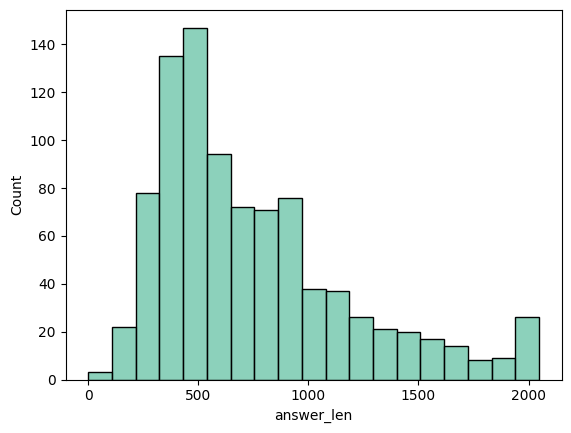

In [290]:
sns.histplot(sgg_df['answer_len'])


## Counting the frames for each video segment

In [291]:
sgg_df['stsg']


0      Here’s a scene graph representing the objects ...
1      Okay, here’s a scene graph representing the ob...
2      Here’s a scene graph representing the video se...
3      Here’s a scene graph representing the objects ...
4      Okay, here’s a scene graph representing the ob...
                             ...                        
909    Here’s a scene graph representing the events a...
910    Here’s a scene graph representing the observed...
911    Here’s a scene graph representing the objects ...
912    Here’s a scene graph representing the video, i...
913    Here’s a scene graph representing the events a...
Name: stsg, Length: 914, dtype: object

In [293]:
sggx_df = sgg_df[contains_stsg_mask].copy()

sggx_df['frames'] = sggx_df['stsg'].apply(lambda x: re.findall("([Ff]rame\s+\d+)", x))
sggx_df['n_frames'] = sggx_df['frames'].apply(len)
sggx_df['expected_frames'] = sggx_df[['start', 'end']].apply(lambda row: int(row['end'] - row['start']), axis=1)

(sggx_df['n_frames'] - sggx_df['expected_frames']).describe()


count    907.000000
mean       0.232635
std        3.594808
min      -21.000000
25%        0.000000
50%        1.000000
75%        1.000000
max       56.000000
dtype: float64

In [ ]:
sggx_df['frames']

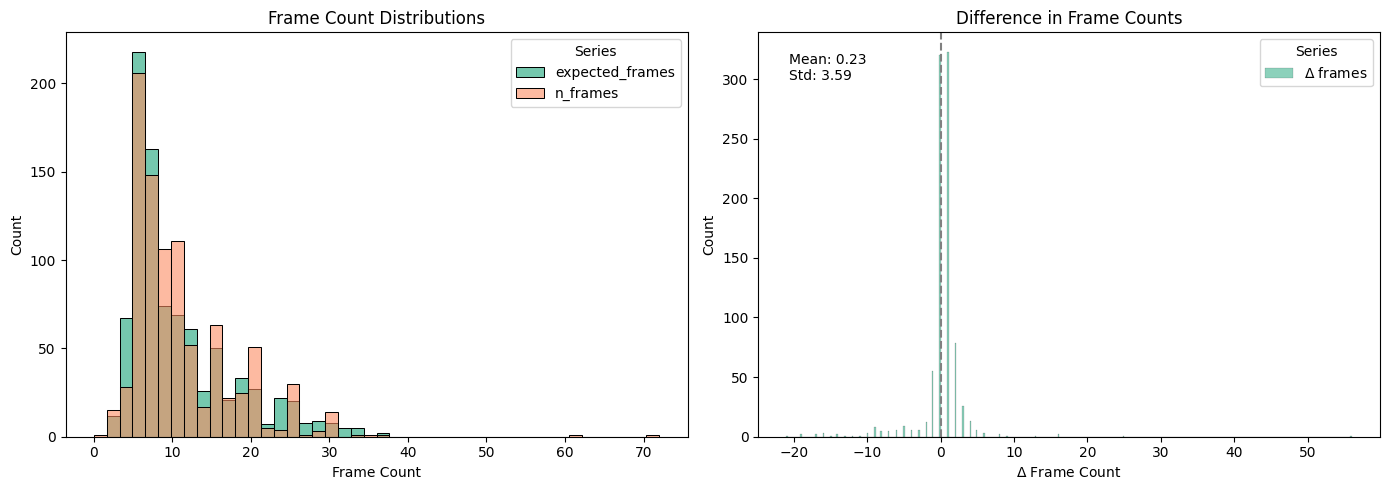

In [294]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frame count distributions
sns.histplot(sggx_df['expected_frames'],    ax=axes[0], alpha=0.9, binrange=(0,sggx_df['n_frames'].max()), label='expected_frames')
sns.histplot(sggx_df['n_frames'],           ax=axes[0], alpha=0.6, binrange=(0,sggx_df['n_frames'].max()), label='n_frames')
axes[0].set_title('Frame Count Distributions')
axes[0].set_xlabel('Frame Count')
axes[0].legend(title='Series')

# Difference distribution with stats
delta = sggx_df['n_frames'] - sggx_df['expected_frames']
sns.histplot(delta, ax=axes[1], label='$\\Delta$ frames')
axes[1].axvline(0, color='grey', linestyle='--')
mean = delta.mean()
std = delta.std()
stats = f"Mean: {mean:.2f}\nStd: {std:.2f}"
axes[1].text(0.05, 0.95, stats, transform=axes[1].transAxes, va='top')
axes[1].set_title('Difference in Frame Counts')
axes[1].set_xlabel('$\\Delta$ Frame Count')
axes[1].legend(title='Series')

plt.tight_layout()
plt.show()


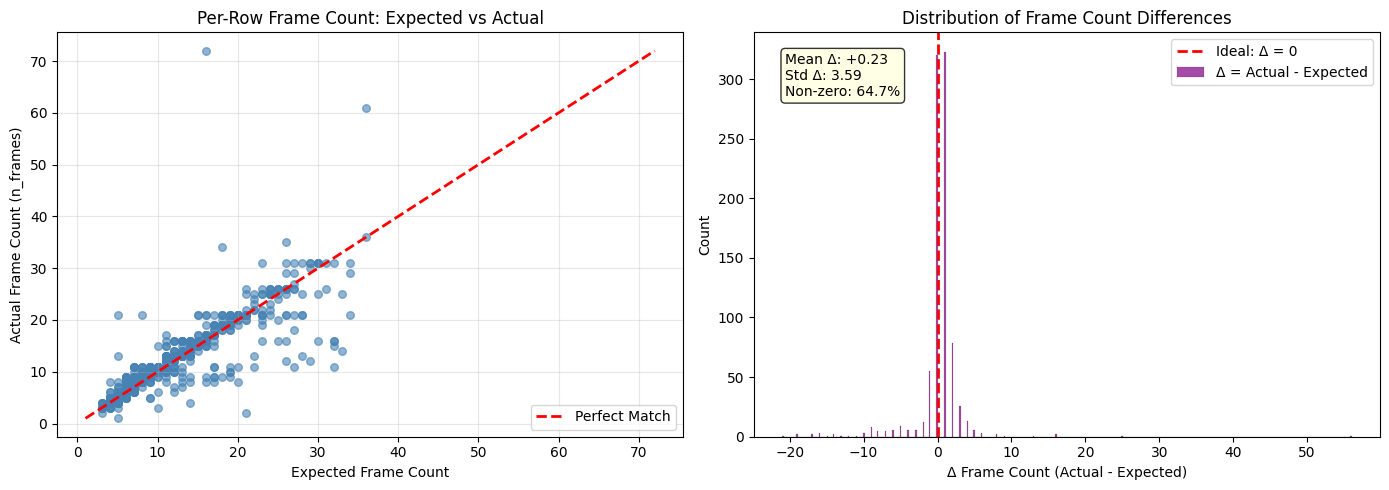

In [295]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Expected vs Actual
axes[0].scatter(sggx_df['expected_frames'], sggx_df['n_frames'], alpha=0.6, s=30, color='steelblue')
lims = [min(sggx_df[['expected_frames', 'n_frames']].min()), 
        max(sggx_df[['expected_frames', 'n_frames']].max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Match')
axes[0].set_xlabel('Expected Frame Count')
axes[0].set_ylabel('Actual Frame Count (n_frames)')
axes[0].set_title('Per-Row Frame Count: Expected vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Difference plot
delta = sggx_df['n_frames'] - sggx_df['expected_frames']
sns.histplot(delta, ax=axes[1], color='purple', alpha=0.7, label='Δ = Actual - Expected')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='Ideal: Δ = 0')
mean = delta.mean()
std = delta.std()
nonzero_pct = (delta != 0).mean() * 100
stats = f"Mean Δ: {mean:+.2f}\nStd Δ: {std:.2f}\nNon-zero: {nonzero_pct:.1f}%"
axes[1].text(0.05, 0.95, stats, transform=axes[1].transAxes, va='top', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
axes[1].set_title('Distribution of Frame Count Differences')
axes[1].set_xlabel('Δ Frame Count (Actual - Expected)')
axes[1].legend()

plt.tight_layout()
plt.show()

DIFFERENCE ANALYSIS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset size: 907 samples

Central Tendency:
• Mean difference: 0.23
• Median difference: 1.00
• Mode region: [0.0, 1.0]

Spread & Variability:
• Standard deviation: 3.59
• IQR: 1.00
• Range: [-21, 56]

Error Metrics:
• Mean Absolute Error: 1.55
• Root Mean Square Error: 3.60
• Mean Absolute Percentage Error: 13.8%

Agreement Levels:
• Perfect matches (Δ=0): 320 (35.3%)
• Very close (|Δ|≤1): 698 (77.0%)
• Close (|Δ|≤2): 789 (87.0%)
• Moderate (|Δ|≤5): 855 (94.3%)
• Large differences (|Δ|>5): 52 (5.7%)

Bias Analysis:
• Over-predictions (Δ<0): 129 (14.2%)
• Under-predictions (Δ>0): 458 (50.5%)
• Systematic bias: Minimal



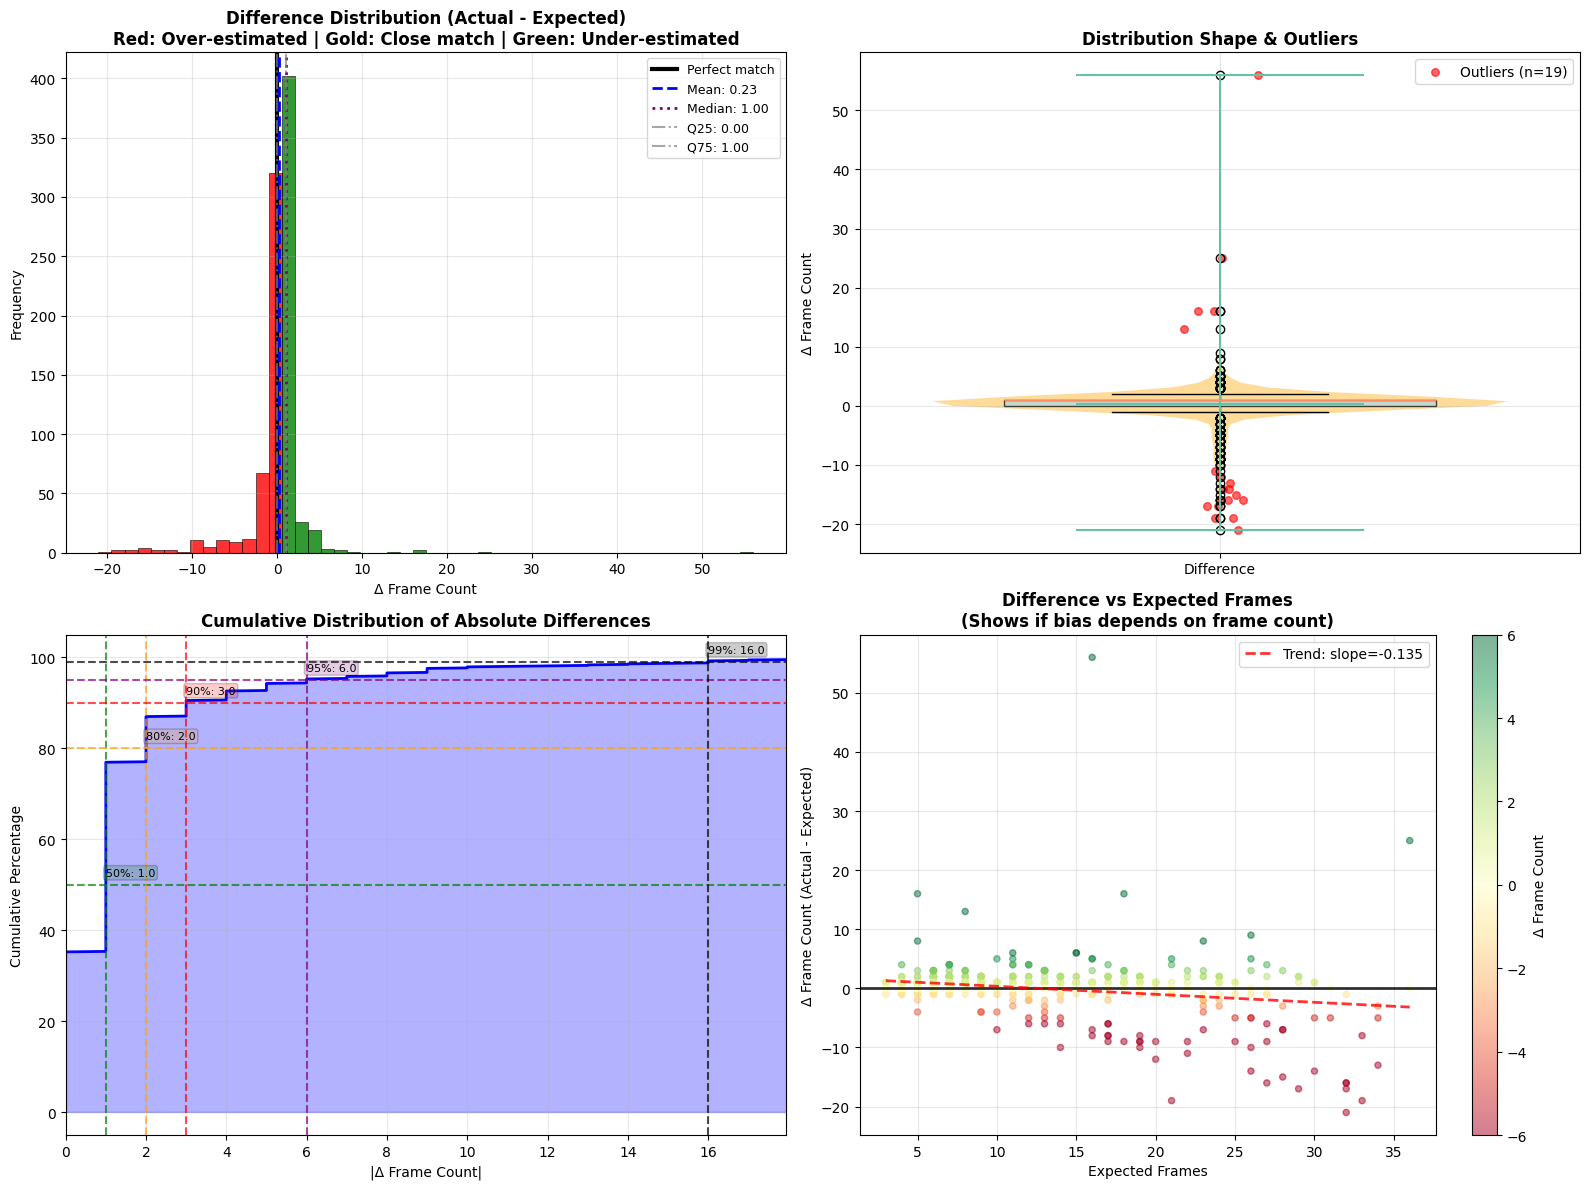


EXTREME CASES ANALYSIS

Top 5 Over-predictions (Expected too high):
  1. Expected: 32, Actual: 11, Diff: -21
  2. Expected: 21, Actual: 2, Diff: -19
  3. Expected: 33, Actual: 14, Diff: -19
  4. Expected: 29, Actual: 12, Diff: -17
  5. Expected: 32, Actual: 15, Diff: -17

Top 5 Under-predictions (Expected too low):
  1. Expected: 16, Actual: 72, Diff: 56
  2. Expected: 36, Actual: 61, Diff: 25
  3. Expected: 5, Actual: 21, Diff: 16
  4. Expected: 18, Actual: 34, Diff: 16
  5. Expected: 8, Actual: 21, Diff: 13


In [296]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Create a comprehensive difference-focused analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate the difference
delta = sggx_df['n_frames'] - sggx_df['expected_frames']

# 1. Enhanced difference histogram with color coding
n, bins, patches = axes[0,0].hist(delta, bins=50, alpha=0.8, edgecolor='black', linewidth=0.5)

# Color bars based on positive/negative/zero
for i, (patch, bin_val) in enumerate(zip(patches, bins[:-1])):
    if bin_val < -0.5:
        patch.set_facecolor('red')
        patch.set_alpha(0.8)
    elif bin_val > 0.5:
        patch.set_facecolor('green') 
        patch.set_alpha(0.8)
    elif -0.5 <= bin_val <= 0.5:
        patch.set_facecolor('gold')
        patch.set_alpha(0.9)

# Add reference lines and statistics
axes[0,0].axvline(0, color='black', linestyle='-', linewidth=3, label='Perfect match')
axes[0,0].axvline(delta.mean(), color='blue', linestyle='--', linewidth=2, 
                  label=f'Mean: {delta.mean():.2f}')
axes[0,0].axvline(delta.median(), color='purple', linestyle=':', linewidth=2, 
                  label=f'Median: {delta.median():.2f}')

# Add quartile lines
q25, q75 = delta.quantile([0.25, 0.75])
axes[0,0].axvline(q25, color='gray', linestyle='-.', alpha=0.7, label=f'Q25: {q25:.2f}')
axes[0,0].axvline(q75, color='gray', linestyle='-.', alpha=0.7, label=f'Q75: {q75:.2f}')

axes[0,0].set_title('Difference Distribution (Actual - Expected)\nRed: Over-estimated | Gold: Close match | Green: Under-estimated', 
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Δ Frame Count')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend(loc='upper right', fontsize=9)
axes[0,0].grid(True, alpha=0.3)

# 2. Box plot and violin plot combination
bp = axes[0,1].boxplot(delta, patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

# Add violin plot overlay
vp = axes[0,1].violinplot([delta], positions=[1], widths=0.8, showmeans=True, showmedians=False)
vp['bodies'][0].set_alpha(0.4)
vp['bodies'][0].set_facecolor('orange')

# Add scatter of outliers
outliers = delta[np.abs(delta - delta.mean()) > 3 * delta.std()]
if len(outliers) > 0:
    y_pos = np.random.normal(1, 0.02, len(outliers))  # Add small jitter
    axes[0,1].scatter(y_pos, outliers, alpha=0.6, color='red', s=30, label=f'Outliers (n={len(outliers)})')

axes[0,1].set_title('Distribution Shape & Outliers', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Δ Frame Count')
axes[0,1].set_xticklabels(['Difference'])
axes[0,1].grid(True, alpha=0.3)
if len(outliers) > 0:
    axes[0,1].legend()

# 3. Cumulative distribution of absolute differences
abs_delta = np.abs(delta)
sorted_abs_delta = np.sort(abs_delta)
cumulative_pct = np.arange(1, len(sorted_abs_delta) + 1) / len(sorted_abs_delta) * 100

axes[1,0].plot(sorted_abs_delta, cumulative_pct, 'b-', linewidth=2, label='Cumulative %')
axes[1,0].fill_between(sorted_abs_delta, cumulative_pct, alpha=0.3, color='blue')

# Add reference lines for key percentiles
percentiles = [50, 80, 90, 95, 99]
colors = ['green', 'orange', 'red', 'purple', 'black']
for pct, color in zip(percentiles, colors):
    value = np.percentile(abs_delta, pct)
    axes[1,0].axhline(pct, color=color, linestyle='--', alpha=0.7)
    axes[1,0].axvline(value, color=color, linestyle='--', alpha=0.7)
    axes[1,0].text(value, pct + 2, f'{pct}%: {value:.1f}', fontsize=8, 
                   bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.2))

axes[1,0].set_title('Cumulative Distribution of Absolute Differences', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('|Δ Frame Count|')
axes[1,0].set_ylabel('Cumulative Percentage')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlim(0, np.percentile(abs_delta, 99.5))  # Trim extreme outliers for better view

# 4. Difference vs Expected frames (to see if bias depends on frame count)
scatter = axes[1,1].scatter(sggx_df['expected_frames'], delta, alpha=0.5, s=20, c=delta, 
                           cmap='RdYlGn', vmin=-np.percentile(np.abs(delta), 95), 
                           vmax=np.percentile(np.abs(delta), 95))
axes[1,1].axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.8)

# Add trend line
z = np.polyfit(sggx_df['expected_frames'], delta, 1)
p = np.poly1d(z)
x_trend = np.linspace(sggx_df['expected_frames'].min(), sggx_df['expected_frames'].max(), 100)
axes[1,1].plot(x_trend, p(x_trend), "r--", linewidth=2, alpha=0.8, 
               label=f'Trend: slope={z[0]:.3f}')

# Add colorbar
plt.colorbar(scatter, ax=axes[1,1], label='Δ Frame Count')

axes[1,1].set_title('Difference vs Expected Frames\n(Shows if bias depends on frame count)', 
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Expected Frames')
axes[1,1].set_ylabel('Δ Frame Count (Actual - Expected)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()

# Add comprehensive statistics text box
stats_text = f"""DIFFERENCE ANALYSIS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dataset size: {len(delta):,} samples

Central Tendency:
• Mean difference: {delta.mean():.2f}
• Median difference: {delta.median():.2f}
• Mode region: [{np.percentile(delta, 45):.1f}, {np.percentile(delta, 55):.1f}]

Spread & Variability:
• Standard deviation: {delta.std():.2f}
• IQR: {delta.quantile(0.75) - delta.quantile(0.25):.2f}
• Range: [{delta.min():.0f}, {delta.max():.0f}]

Error Metrics:
• Mean Absolute Error: {np.abs(delta).mean():.2f}
• Root Mean Square Error: {np.sqrt((delta**2).mean()):.2f}
• Mean Absolute Percentage Error: {(np.abs(delta) / sggx_df['expected_frames']).mean() * 100:.1f}%

Agreement Levels:
• Perfect matches (Δ=0): {sum(delta == 0):,} ({sum(delta == 0)/len(delta)*100:.1f}%)
• Very close (|Δ|≤1): {sum(np.abs(delta) <= 1):,} ({sum(np.abs(delta) <= 1)/len(delta)*100:.1f}%)
• Close (|Δ|≤2): {sum(np.abs(delta) <= 2):,} ({sum(np.abs(delta) <= 2)/len(delta)*100:.1f}%)
• Moderate (|Δ|≤5): {sum(np.abs(delta) <= 5):,} ({sum(np.abs(delta) <= 5)/len(delta)*100:.1f}%)
• Large differences (|Δ|>5): {sum(np.abs(delta) > 5):,} ({sum(np.abs(delta) > 5)/len(delta)*100:.1f}%)

Bias Analysis:
• Over-predictions (Δ<0): {sum(delta < 0):,} ({sum(delta < 0)/len(delta)*100:.1f}%)
• Under-predictions (Δ>0): {sum(delta > 0):,} ({sum(delta > 0)/len(delta)*100:.1f}%)
• Systematic bias: {'Yes' if abs(delta.mean()) > 0.5 else 'Minimal'}
"""

print(stats_text)
plt.show()

# Additional analysis: Show worst cases
print(f"\n{'='*50}")
print("EXTREME CASES ANALYSIS")
print(f"{'='*50}")

# Largest over-predictions
worst_over = delta.nsmallest(5)
print(f"\nTop 5 Over-predictions (Expected too high):")
for i, idx in enumerate(worst_over.index):
    exp = sggx_df.loc[idx, 'expected_frames']
    act = sggx_df.loc[idx, 'n_frames'] 
    diff = worst_over.iloc[i]
    print(f"  {i+1}. Expected: {exp}, Actual: {act}, Diff: {diff}")

# Largest under-predictions  
worst_under = delta.nlargest(5)
print(f"\nTop 5 Under-predictions (Expected too low):")
for i, idx in enumerate(worst_under.index):
    exp = sggx_df.loc[idx, 'expected_frames']
    act = sggx_df.loc[idx, 'n_frames']
    diff = worst_under.iloc[i] 
    print(f"  {i+1}. Expected: {exp}, Actual: {act}, Diff: {diff}")

In [297]:
from scipy import stats
d = sggx_df['n_frames'] - sggx_df['expected_frames']
stat, p = stats.ttest_1samp(d, 0)
print(f"t={stat:.3f}, p={p:.3f}")


t=1.949, p=0.052


We can see that the model behaves well in detecting the number of frames when given the text delimiter between images.

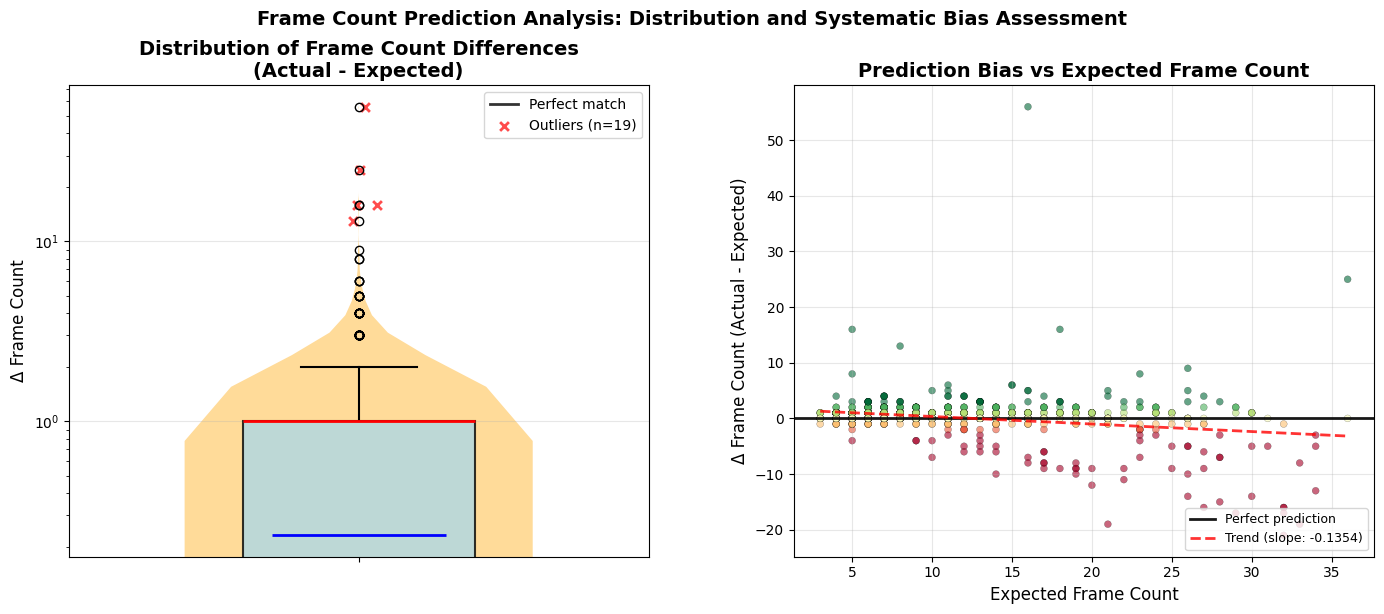


THESIS STATISTICS - FOR CAPTION/TEXT:

Figure Caption Stats:
MAE = 1.55, RMSE = 3.60, r = -0.257
87.0% within ±2 frames, 320 perfect matches

Detailed Results for Main Text:
• Dataset size: 907 predictions
• Mean prediction error: 0.23 ± 3.59 frames
• Median error: 1.00 frames
• Interquartile range: 0.00 to 1.00 frames
• Error range: [-21, 56] frames
• Mean Absolute Error: 1.55 frames
• Root Mean Square Error: 3.60 frames

Prediction Accuracy:
• Perfect predictions (Δ = 0): 320 (35.3%)
• High accuracy (|Δ| ≤ 2): 789 (87.0%)
• Moderate accuracy (|Δ| ≤ 5): 855 (94.3%)

Bias Analysis:
• Minimal systematic bias: 0.23 frames
• Error correlation with expected frames: r = -0.257
  (prediction error decreases with higher expected frame counts)

Suggested Figure Caption:

Frame count prediction accuracy analysis. (a) Distribution of prediction errors 
(Δ = actual - expected frames) showing 320 perfect matches and overall error 
statistics (μ = 0.23, σ = 3.59). (b) Prediction bias versus expect

In [298]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set professional style for thesis
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Create horizontal layout for thesis embedding
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calculate the difference
delta = sggx_df['n_frames'] - sggx_df['expected_frames']

# 1. Enhanced violin plot with box plot overlay
bp = axes[0].boxplot(delta, patch_artist=True, widths=0.4, 
                     boxprops=dict(facecolor='lightblue', alpha=0.8, linewidth=1.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     medianprops=dict(color='red', linewidth=2))

# Add violin plot overlay
vp = axes[0].violinplot([delta], positions=[1], widths=0.6, showmeans=True, 
                       showmedians=False, showextrema=False)
vp['bodies'][0].set_alpha(0.4)
vp['bodies'][0].set_facecolor('orange')
vp['cmeans'].set_color('blue')
vp['cmeans'].set_linewidth(2)

# Add zero reference line
axes[0].axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.8, label='Perfect match')

# Calculate key statistics for separate reporting
mean_val = delta.mean()
median_val = delta.median()
std_val = delta.std()
q25, q75 = delta.quantile([0.25, 0.75])

# Identify and mark outliers
outlier_threshold = 3 * std_val
outliers = delta[np.abs(delta - mean_val) > outlier_threshold]
if len(outliers) > 0:
    y_pos = np.random.normal(1, 0.02, len(outliers))
    scatter = axes[0].scatter(y_pos, outliers, alpha=0.7, color='red', s=40, 
                             marker='x', linewidth=2, label=f'Outliers (n={len(outliers)})')

axes[0].set_title('Distribution of Frame Count Differences\n(Actual - Expected)', 
                  fontweight='bold')
axes[0].set_ylabel('Δ Frame Count')
axes[0].set_xticklabels([''])
axes[0].semilogy()
axes[0].grid(True, alpha=0.3, axis='y')
if len(outliers) > 0:
    axes[0].legend(loc='upper right')

# 2. Difference vs Expected frames with enhanced visualization
# Create scatter plot with density-based coloring
scatter = axes[1].scatter(sggx_df['expected_frames'], delta, alpha=0.6, s=25, 
                         c=delta, cmap='RdYlGn', 
                         vmin=-np.percentile(np.abs(delta), 90), 
                         vmax=np.percentile(np.abs(delta), 90),
                         edgecolors='black', linewidth=0.2)

# Add perfect prediction line
axes[1].axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.9, 
                label='Perfect prediction')

# Add trend line with confidence interval
z = np.polyfit(sggx_df['expected_frames'], delta, 1)
p = np.poly1d(z)
x_trend = np.linspace(sggx_df['expected_frames'].min(), sggx_df['expected_frames'].max(), 100)
y_trend = p(x_trend)

axes[1].plot(x_trend, y_trend, "r--", linewidth=2, alpha=0.8, 
             label=f'Trend (slope: {z[0]:.4f})')

# Calculate correlation for separate reporting
correlation = np.corrcoef(sggx_df['expected_frames'], delta)[0, 1]
r_squared = correlation ** 2

axes[1].set_title('Prediction Bias vs Expected Frame Count', fontweight='bold')
axes[1].set_xlabel('Expected Frame Count')
axes[1].set_ylabel('Δ Frame Count (Actual - Expected)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Adjust layout for thesis embedding
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)

# Add figure caption-style summary
fig.suptitle('Frame Count Prediction Analysis: Distribution and Systematic Bias Assessment', 
             fontsize=14, fontweight='bold', y=1.02)

plt.show()

# Generate thesis-ready statistics for separate reporting
print("\nTHESIS STATISTICS - FOR CAPTION/TEXT:")
print("=" * 60)

# Key metrics
mae = np.abs(delta).mean()
rmse = np.sqrt((delta**2).mean())
perfect_matches = sum(delta == 0)
close_matches = sum(np.abs(delta) <= 2)
moderate_matches = sum(np.abs(delta) <= 5)

print(f"\nFigure Caption Stats:")
print(f"MAE = {mae:.2f}, RMSE = {rmse:.2f}, r = {correlation:.3f}")
print(f"{close_matches/len(delta)*100:.1f}% within ±2 frames, {perfect_matches} perfect matches")

print(f"\nDetailed Results for Main Text:")
print(f"• Dataset size: {len(delta):,} predictions")
print(f"• Mean prediction error: {mean_val:.2f} ± {std_val:.2f} frames")
print(f"• Median error: {median_val:.2f} frames")
print(f"• Interquartile range: {q25:.2f} to {q75:.2f} frames")
print(f"• Error range: [{delta.min():.0f}, {delta.max():.0f}] frames")
print(f"• Mean Absolute Error: {mae:.2f} frames")  
print(f"• Root Mean Square Error: {rmse:.2f} frames")

print(f"\nPrediction Accuracy:")
print(f"• Perfect predictions (Δ = 0): {perfect_matches:,} ({perfect_matches/len(delta)*100:.1f}%)")
print(f"• High accuracy (|Δ| ≤ 2): {close_matches:,} ({close_matches/len(delta)*100:.1f}%)")
print(f"• Moderate accuracy (|Δ| ≤ 5): {moderate_matches:,} ({moderate_matches/len(delta)*100:.1f}%)")

print(f"\nBias Analysis:")
if abs(mean_val) > 0.5:
    bias_direction = "under-prediction" if mean_val > 0 else "over-prediction"
    print(f"• Systematic bias detected: {bias_direction} by {abs(mean_val):.2f} frames on average")
else:
    print(f"• Minimal systematic bias: {mean_val:.2f} frames")

if abs(correlation) > 0.1:
    trend = "increases" if correlation > 0 else "decreases" 
    print(f"• Error correlation with expected frames: r = {correlation:.3f}")
    print(f"  (prediction error {trend} with higher expected frame counts)")
else:
    print(f"• No significant correlation with expected frames (r = {correlation:.3f})")

print(f"\nSuggested Figure Caption:")
caption = f"""Frame count prediction accuracy analysis. (a) Distribution of prediction errors 
(Δ = actual - expected frames) showing {perfect_matches} perfect matches and overall error 
statistics (μ = {mean_val:.2f}, σ = {std_val:.2f}). (b) Prediction bias versus expected frame 
count, revealing {'systematic bias' if abs(correlation) > 0.1 else 'no systematic bias'} 
(r = {correlation:.3f}). Overall accuracy: MAE = {mae:.2f}, RMSE = {rmse:.2f}, with 
{close_matches/len(delta)*100:.1f}% of predictions within ±2 frames."""

print(f"\n{caption}")

# Generate LaTeX table if needed
print(f"\nLaTeX Table Code (optional):")
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{Frame Count Prediction Statistics}")
print(r"\begin{tabular}{lr}")
print(r"\hline")
print(r"Metric & Value \\")
print(r"\hline")
print(f"Mean Error & {mean_val:.2f} \\\\")
print(f"Standard Deviation & {std_val:.2f} \\\\") 
print(f"Mean Absolute Error & {mae:.2f} \\\\")
print(f"Root Mean Square Error & {rmse:.2f} \\\\")
print(f"Perfect Matches (\%) & {perfect_matches/len(delta)*100:.1f} \\\\")
print(f"Within ±2 frames (\%) & {close_matches/len(delta)*100:.1f} \\\\")
print(f"Correlation (r) & {correlation:.3f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

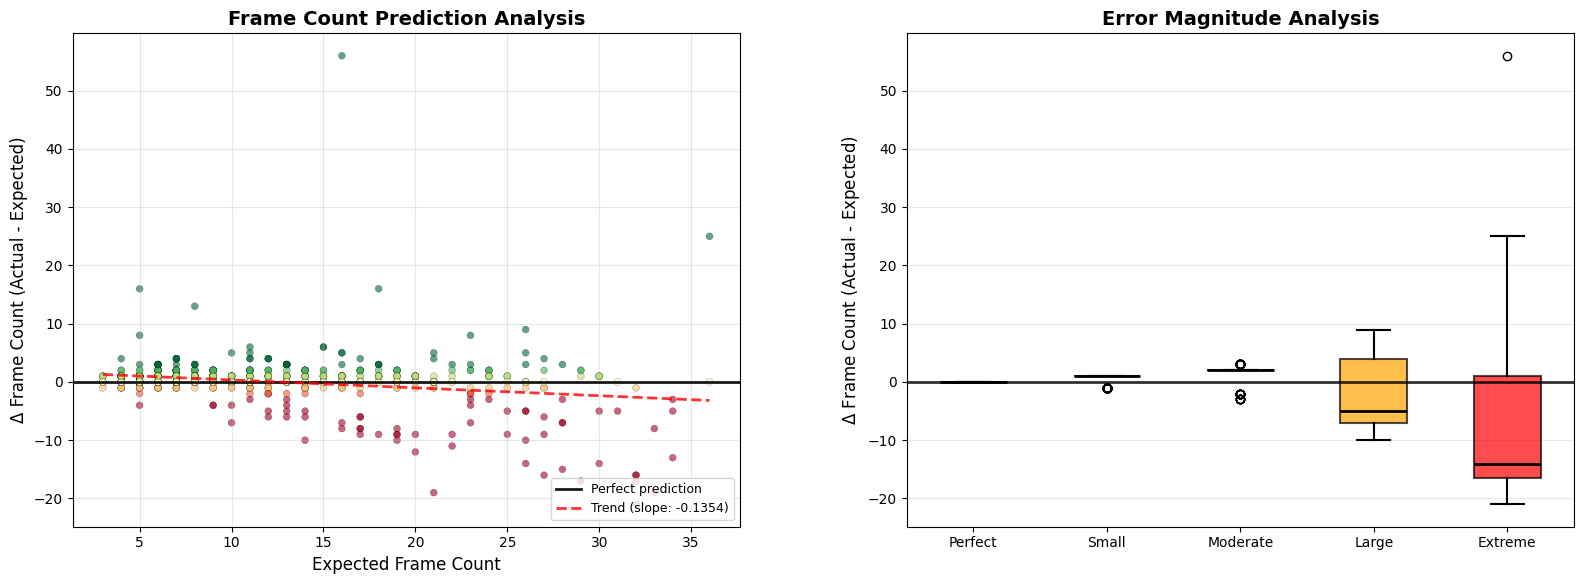

In [322]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set professional style for thesis
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Create horizontal layout for thesis embedding
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate the difference
delta = sggx_df['n_frames'] - sggx_df['expected_frames']

# 1. RESIDUAL PLOT (enhanced version)
# 2. Difference vs Expected frames with enhanced visualization
# Create scatter plot with density-based coloring
scatter = axes[0].scatter(sggx_df['expected_frames'], delta, alpha=0.6, s=25, 
                         c=delta, cmap='RdYlGn', 
                         vmin=-np.percentile(np.abs(delta), 90), 
                         vmax=np.percentile(np.abs(delta), 90),
                         edgecolors='black', linewidth=0.2)

# Add perfect prediction line
axes[0].axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.9, 
                label='Perfect prediction')

# Add trend line with confidence interval
z = np.polyfit(sggx_df['expected_frames'], delta, 1)
p = np.poly1d(z)
x_trend = np.linspace(sggx_df['expected_frames'].min(), sggx_df['expected_frames'].max(), 100)
y_trend = p(x_trend)

axes[0].plot(x_trend, y_trend, "r--", linewidth=2, alpha=0.8, 
             label=f'Trend (slope: {z[0]:.4f})')

# Calculate correlation for separate reporting
correlation = np.corrcoef(sggx_df['expected_frames'], delta)[0, 1]
r_squared = correlation ** 2

axes[0].set_title('Frame Count Prediction Analysis', fontweight='bold')
axes[0].set_xlabel('Expected Frame Count')
axes[0].set_ylabel('Δ Frame Count (Actual - Expected)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. ERROR ANALYSIS BY MAGNITUDE (enhanced box plot)
# Create error magnitude categories with better thresholds
abs_errors = np.abs(delta)

# Define categories
perfect = delta[abs_errors == 0]
small = delta[(abs_errors > 0) & (abs_errors <= 1)]
moderate = delta[(abs_errors > 1) & (abs_errors <= 3)]
large = delta[(abs_errors > 3) & (abs_errors <= 10)]
extreme = delta[abs_errors > 10]

# Prepare data for box plot - clean labels without statistics
data_for_boxplot = []
labels_for_boxplot = []
colors = []

categories = [
    (perfect, 'Perfect', 'darkgreen'),
    (small, 'Small', 'lightgreen'),
    (moderate, 'Moderate', 'yellow'),
    (large, 'Large', 'orange'),
    (extreme, 'Extreme', 'red')
]

for data, label, color in categories:
    if len(data) > 0:
        data_for_boxplot.append(data)
        labels_for_boxplot.append(label)
        colors.append(color)

# Create box plot
bp = axes[1].boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True,
                     boxprops=dict(linewidth=1.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     medianprops=dict(color='black', linewidth=2))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add perfect prediction reference
axes[1].axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.8, 
                label='Perfect prediction')

# Calculate statistics for separate reporting (not displayed on plot)
mae = np.abs(delta).mean()
rmse = np.sqrt((delta**2).mean())
mean_bias = delta.mean()

# Calculate category percentages for summary
n_perfect = len(perfect)
n_acceptable = len(small) + len(moderate)  # ≤3 frames
n_problematic = len(large) + len(extreme)  # >3 frames

axes[1].set_title('Error Magnitude Analysis', fontweight='bold')
axes[1].set_ylabel('$\Delta$ Frame Count (Actual - Expected)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.savefig('sgg_frame_count.svg', dpi=300)

plt.show()

In [ ]:
# Generate comprehensive statistics for thesis
print("\n" + "="*70)
print("COMPREHENSIVE STATISTICS FOR THESIS")
print("="*70)

# Basic statistics
print(f"\nDataset Overview:")
print(f"• Total predictions: {len(delta):,}")
print(f"• Expected frames range: [{sggx_df['expected_frames'].min():.0f}, {sggx_df['expected_frames'].max():.0f}]")
print(f"• Actual frames range: [{sggx_df['n_frames'].min():.0f}, {sggx_df['n_frames'].max():.0f}]")

print(f"\nError Statistics:")
print(f"• Mean error (bias): {mean_bias:.3f} frames")
print(f"• Standard deviation: {delta.std():.3f} frames")
print(f"• Mean Absolute Error: {mae:.3f} frames")
print(f"• Root Mean Square Error: {rmse:.3f} frames")
print(f"• Median error: {delta.median():.3f} frames")
print(f"• Error range: [{delta.min():.0f}, {delta.max():.0f}] frames")

print(f"\nAccuracy Breakdown:")
for i, (data, label, _) in enumerate(categories):
    if len(data) > 0:
        count = len(data)
        percentage = count / len(delta) * 100
        category_name = label.split('\n')[0]
        print(f"• {category_name:12}: {count:,} predictions ({percentage:.1f}%)")

print(f"\nBias Analysis:")
if abs(correlation) > 0.1:
    trend_desc = "increases" if correlation > 0 else "decreases"
    print(f"• Systematic bias detected: error {trend_desc} with expected frame count")
    print(f"• Correlation coefficient: r = {correlation:.3f}")
else:
    print(f"• No significant systematic bias detected (r = {correlation:.3f})")

if abs(mean_bias) > 0.5:
    bias_type = "under-prediction" if mean_bias > 0 else "over-prediction"
    print(f"• Overall tendency: {bias_type} by {abs(mean_bias):.2f} frames on average")
else:
    print(f"• Minimal overall bias: {mean_bias:.3f} frames")

print(f"\nModel Performance Assessment:")
perfect_pct = n_perfect / len(delta) * 100
acceptable_pct = n_acceptable / len(delta) * 100
if perfect_pct > 20:
    print(f"• Excellent precision: {perfect_pct:.1f}% perfect predictions")
elif acceptable_pct > 80:
    print(f"• Good accuracy: {acceptable_pct:.1f}% within 3 frames")
elif acceptable_pct > 60:
    print(f"• Moderate accuracy: {acceptable_pct:.1f}% within 3 frames")
else:
    print(f"• Needs improvement: only {acceptable_pct:.1f}% within 3 frames")

print(f"\n" + "="*70)
print("SUGGESTED FIGURE CAPTION:")
print("="*70)
caption = f"""Frame count prediction analysis using residual plots and error classification. 
(a) Residual plot showing prediction errors versus expected frame counts, with trend line 
(slope = {z[0]:.4f}) and moving average revealing {'systematic bias' if abs(correlation) > 0.1 else 'minimal bias'} 
(r = {correlation:.3f}). Color intensity represents error magnitude. (b) Error magnitude 
classification showing distribution across accuracy categories, with {perfect_pct:.1f}% perfect 
predictions and {acceptable_pct:.1f}% within acceptable limits (≤3 frames). Overall performance: 
MAE = {mae:.2f}, RMSE = {rmse:.2f}."""

print(caption)

print(f"\n" + "="*70)
print("KEY INSIGHTS FOR THESIS TEXT:")
print("="*70)
print(f"• The model achieves high accuracy with {perfect_pct:.1f}% perfect predictions")
print(f"• {acceptable_pct:.1f}% of predictions fall within acceptable error margins (≤3 frames)")
print(f"• Mean absolute error of {mae:.2f} frames indicates strong predictive performance")
if abs(correlation) > 0.1:
    print(f"• Systematic bias present: errors correlate with expected frame count (r = {correlation:.3f})")
else:
    print(f"• No systematic bias: errors are independent of expected frame count")
print(f"• Error distribution shows {'symmetric' if abs(mean_bias) < 0.5 else 'asymmetric'} pattern around zero")

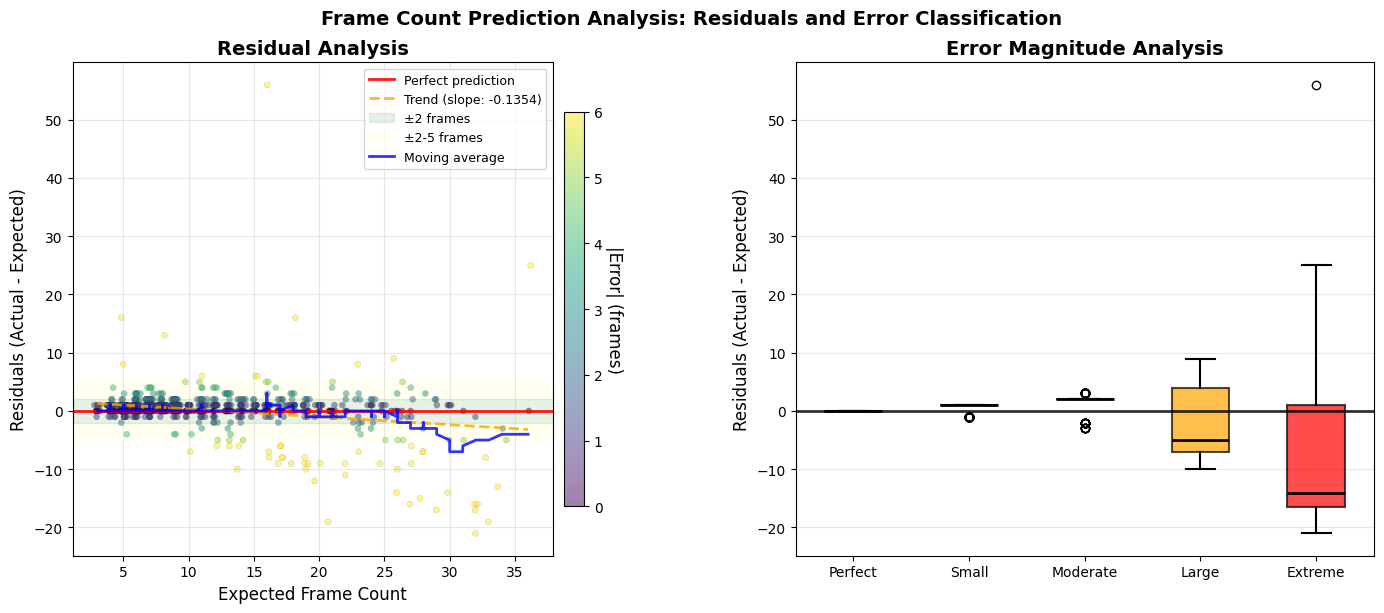


COMPREHENSIVE STATISTICS FOR THESIS

Dataset Overview:
• Total predictions: 907
• Expected frames range: [3, 36]
• Actual frames range: [1, 72]

Error Statistics:
• Mean error (bias): 0.233 frames
• Standard deviation: 3.595 frames
• Mean Absolute Error: 1.553 frames
• Root Mean Square Error: 3.600 frames
• Median error: 1.000 frames
• Error range: [-21, 56] frames

Accuracy Breakdown:
• Perfect     : 320 predictions (35.3%)
• Small       : 378 predictions (41.7%)
• Moderate    : 123 predictions (13.6%)
• Large       : 67 predictions (7.4%)
• Extreme     : 19 predictions (2.1%)

Bias Analysis:
• Systematic bias detected: error decreases with expected frame count
• Correlation coefficient: r = -0.257
• Minimal overall bias: 0.233 frames

Model Performance Assessment:
• Excellent precision: 35.3% perfect predictions

SUGGESTED FIGURE CAPTION:
Frame count prediction analysis using residual plots and error classification. 
(a) Residual plot showing prediction errors versus expected frame 

In [312]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set professional style for thesis
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Create horizontal layout for thesis embedding
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calculate the difference
delta = sggx_df['n_frames'] - sggx_df['expected_frames']

# 1. RESIDUAL PLOT (enhanced version)
# Add slight jitter to reduce overplotting
jitter_strength = (sggx_df['expected_frames'].max() - sggx_df['expected_frames'].min()) * 0.005
jittered_x = sggx_df['expected_frames'] + np.random.normal(0, jitter_strength, len(sggx_df))

scatter = axes[0].scatter(jittered_x, delta, alpha=0.5, s=20, 
                         c=np.abs(delta), cmap='viridis', 
                         vmax=np.percentile(np.abs(delta), 95),
                         edgecolors='black', linewidth=0.1)

# Perfect prediction line
axes[0].axhline(0, color='red', linestyle='-', linewidth=2, alpha=0.9, 
                label='Perfect prediction')

# Trend line
z = np.polyfit(sggx_df['expected_frames'], delta, 1)
p = np.poly1d(z)
x_trend = np.linspace(sggx_df['expected_frames'].min(), sggx_df['expected_frames'].max(), 100)
y_trend = p(x_trend)
axes[0].plot(x_trend, y_trend, "orange", linestyle='--', linewidth=2, alpha=0.8, 
             label=f'Trend (slope: {z[0]:.4f})')

# Confidence bands for acceptable error
axes[0].axhspan(-2, 2, alpha=0.1, color='green', label='±2 frames')
axes[0].axhspan(-5, -2, alpha=0.05, color='yellow')
axes[0].axhspan(2, 5, alpha=0.05, color='yellow', label='±2-5 frames')

# Moving average trend (smoother)
from scipy.ndimage import uniform_filter1d
window_size = max(20, len(sggx_df) // 40)
sorted_indices = np.argsort(sggx_df['expected_frames'])
sorted_expected = sggx_df['expected_frames'].iloc[sorted_indices]
sorted_delta = delta.iloc[sorted_indices]
moving_avg = uniform_filter1d(sorted_delta, size=window_size, mode='nearest')
axes[0].plot(sorted_expected, moving_avg, color='blue', linewidth=2, alpha=0.8, 
             label='Moving average')

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[0], shrink=0.8, aspect=20, pad=0.02)
cbar.set_label('|Error| (frames)', rotation=270, labelpad=15)

correlation = np.corrcoef(sggx_df['expected_frames'], delta)[0, 1]

axes[0].set_title('Residual Analysis', fontweight='bold')
axes[0].set_xlabel('Expected Frame Count')
axes[0].set_ylabel('Residuals (Actual - Expected)')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. ERROR ANALYSIS BY MAGNITUDE (enhanced box plot)
# Create error magnitude categories with better thresholds
abs_errors = np.abs(delta)

# Define categories
perfect = delta[abs_errors == 0]
small = delta[(abs_errors > 0) & (abs_errors <= 1)]
moderate = delta[(abs_errors > 1) & (abs_errors <= 3)]
large = delta[(abs_errors > 3) & (abs_errors <= 10)]
extreme = delta[abs_errors > 10]

# Prepare data for box plot - clean labels without statistics
data_for_boxplot = []
labels_for_boxplot = []
colors = []

categories = [
    (perfect, 'Perfect', 'darkgreen'),
    (small, 'Small', 'lightgreen'),
    (moderate, 'Moderate', 'yellow'),
    (large, 'Large', 'orange'),
    (extreme, 'Extreme', 'red')
]

for data, label, color in categories:
    if len(data) > 0:
        data_for_boxplot.append(data)
        labels_for_boxplot.append(label)
        colors.append(color)

# Create box plot
bp = axes[1].boxplot(data_for_boxplot, labels=labels_for_boxplot, patch_artist=True,
                     boxprops=dict(linewidth=1.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     medianprops=dict(color='black', linewidth=2))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add perfect prediction reference
axes[1].axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.8, 
                label='Perfect prediction')

# Calculate statistics for separate reporting (not displayed on plot)
mae = np.abs(delta).mean()
rmse = np.sqrt((delta**2).mean())
mean_bias = delta.mean()

# Calculate category percentages for summary
n_perfect = len(perfect)
n_acceptable = len(small) + len(moderate)  # ≤3 frames
n_problematic = len(large) + len(extreme)  # >3 frames

axes[1].set_title('Error Magnitude Analysis', fontweight='bold')
axes[1].set_ylabel('Residuals (Actual - Expected)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)

# Add figure title
fig.suptitle('Frame Count Prediction Analysis: Residuals and Error Classification', 
             fontsize=14, fontweight='bold', y=1.02)

plt.show()

# Generate comprehensive statistics for thesis
print("\n" + "="*70)
print("COMPREHENSIVE STATISTICS FOR THESIS")
print("="*70)

# Basic statistics
print(f"\nDataset Overview:")
print(f"• Total predictions: {len(delta):,}")
print(f"• Expected frames range: [{sggx_df['expected_frames'].min():.0f}, {sggx_df['expected_frames'].max():.0f}]")
print(f"• Actual frames range: [{sggx_df['n_frames'].min():.0f}, {sggx_df['n_frames'].max():.0f}]")

print(f"\nError Statistics:")
print(f"• Mean error (bias): {mean_bias:.3f} frames")
print(f"• Standard deviation: {delta.std():.3f} frames")
print(f"• Mean Absolute Error: {mae:.3f} frames")
print(f"• Root Mean Square Error: {rmse:.3f} frames")
print(f"• Median error: {delta.median():.3f} frames")
print(f"• Error range: [{delta.min():.0f}, {delta.max():.0f}] frames")

print(f"\nAccuracy Breakdown:")
for i, (data, label, _) in enumerate(categories):
    if len(data) > 0:
        count = len(data)
        percentage = count / len(delta) * 100
        category_name = label.split('\n')[0]
        print(f"• {category_name:12}: {count:,} predictions ({percentage:.1f}%)")

print(f"\nBias Analysis:")
if abs(correlation) > 0.1:
    trend_desc = "increases" if correlation > 0 else "decreases"
    print(f"• Systematic bias detected: error {trend_desc} with expected frame count")
    print(f"• Correlation coefficient: r = {correlation:.3f}")
else:
    print(f"• No significant systematic bias detected (r = {correlation:.3f})")

if abs(mean_bias) > 0.5:
    bias_type = "under-prediction" if mean_bias > 0 else "over-prediction"
    print(f"• Overall tendency: {bias_type} by {abs(mean_bias):.2f} frames on average")
else:
    print(f"• Minimal overall bias: {mean_bias:.3f} frames")

print(f"\nModel Performance Assessment:")
perfect_pct = n_perfect / len(delta) * 100
acceptable_pct = n_acceptable / len(delta) * 100
if perfect_pct > 20:
    print(f"• Excellent precision: {perfect_pct:.1f}% perfect predictions")
elif acceptable_pct > 80:
    print(f"• Good accuracy: {acceptable_pct:.1f}% within 3 frames")
elif acceptable_pct > 60:
    print(f"• Moderate accuracy: {acceptable_pct:.1f}% within 3 frames")
else:
    print(f"• Needs improvement: only {acceptable_pct:.1f}% within 3 frames")

print(f"\n" + "="*70)
print("SUGGESTED FIGURE CAPTION:")
print("="*70)
caption = f"""Frame count prediction analysis using residual plots and error classification. 
(a) Residual plot showing prediction errors versus expected frame counts, with trend line 
(slope = {z[0]:.4f}) and moving average revealing {'systematic bias' if abs(correlation) > 0.1 else 'minimal bias'} 
(r = {correlation:.3f}). Color intensity represents error magnitude. (b) Error magnitude 
classification showing distribution across accuracy categories, with {perfect_pct:.1f}% perfect 
predictions and {acceptable_pct:.1f}% within acceptable limits (≤3 frames). Overall performance: 
MAE = {mae:.2f}, RMSE = {rmse:.2f}."""

print(caption)

print(f"\n" + "="*70)
print("KEY INSIGHTS FOR THESIS TEXT:")
print("="*70)
print(f"• The model achieves high accuracy with {perfect_pct:.1f}% perfect predictions")
print(f"• {acceptable_pct:.1f}% of predictions fall within acceptable error margins (≤3 frames)")
print(f"• Mean absolute error of {mae:.2f} frames indicates strong predictive performance")
if abs(correlation) > 0.1:
    print(f"• Systematic bias present: errors correlate with expected frame count (r = {correlation:.3f})")
else:
    print(f"• No systematic bias: errors are independent of expected frame count")
print(f"• Error distribution shows {'symmetric' if abs(mean_bias) < 0.5 else 'asymmetric'} pattern around zero")
